# NGC4064 7000 vs 8900 Product Comparison

Compare NGC4064 products from `v3tk_v7.6.8_7000` against `v3tk_v7.6.8`.

The `_7000` run is the fiducial/reference run. Residual convention in this notebook: `v3tk_v7.6.8 - v3tk_v7.6.8_7000`.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from IPython.display import display

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 160,
    'axes.grid': False,
    'font.size': 10,
})

root = Path('/Users/Igniz/Desktop/ICRAR/further')

RUNS = {
    'fiducial_7000': {
        'label': 'v3tk_v7.6.8_7000',
        'path': root / 'v3tk_v7.6.8_7000' / 'NGC4064',
        'sfh_file': 'NGC4064_sfh_maps.fits',
        'kin_file': 'NGC4064_kin_maps.fits',
        'gas_bin_file': 'NGC4064_gas_bin_maps.fits',
    },
    'test_8900': {
        'label': 'v3tk_v7.6.8',
        'path': root / 'v3tk_v7.6.8' / 'NGC4064',
        'sfh_file': 'NGC4064_sfh_maps.fits',
        'kin_file': 'NGC4064_kin_maps.fits',
        'gas_bin_file': 'NGC4064_gas_bin_maps.fits',
    },
}

MAP_ORDER = ['fiducial_7000', 'test_8900']
REF_KEY = 'fiducial_7000'
TEST_KEY = 'test_8900'

PROPERTIES = {
    'AGE': {
        'label': 'SFH age',
        'file_key': 'sfh_file',
        'hdu': 'AGE',
        'unit': 'Gyr',
        'cmap': 'cividis',
        'scatter_log_axes': True,
    },
    'METAL': {
        'label': 'SFH metallicity',
        'file_key': 'sfh_file',
        'hdu': 'METAL',
        'unit': 'dex',
        'cmap': 'plasma',
    },
    'V': {
        'label': 'stellar velocity',
        'file_key': 'kin_file',
        'hdu': 'V',
        'unit': 'km/s',
        'cmap': 'RdBu_r',
    },
    'SIGMA': {
        'label': 'stellar velocity dispersion',
        'file_key': 'kin_file',
        'hdu': 'SIGMA',
        'unit': 'km/s',
        'cmap': 'magma',
    },
    'HA6562_FLUX': {
        'label': 'Halpha flux',
        'file_key': 'gas_bin_file',
        'hdu': 'HA6562_FLUX',
        'unit': 'flux',
        'cmap': 'inferno',
        'scatter_log_axes': True,
        'scatter_log_residual': True,
    },
    'HA6562_VEL': {
        'label': 'Halpha velocity',
        'file_key': 'gas_bin_file',
        'hdu': 'HA6562_VEL',
        'unit': 'km/s',
        'cmap': 'RdBu_r',
    },
}

for run in RUNS.values():
    for key in ('sfh_file', 'kin_file', 'gas_bin_file'):
        path = run['path'] / run[key]
        if not path.exists():
            raise FileNotFoundError(path)

print('Configured runs:')
for key, run in RUNS.items():
    print(f"  {key:14s}: {run['label']} -> {run['path']}")


Configured runs:
  fiducial_7000 : v3tk_v7.6.8_7000 -> /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8_7000/NGC4064
  test_8900     : v3tk_v7.6.8 -> /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8/NGC4064


## Load Products

Load the requested map HDUs from `_sfh_maps.fits`, `_kin_maps.fits`, and `_gas_bin_maps.fits`. The comparison uses the overlapping finite footprint for each property.


In [2]:
def read_image(path, hdu):
    with fits.open(path, memmap=True) as hdul:
        data = np.array(hdul[hdu].data, dtype=float)
        header = hdul[hdu].header.copy()
    return data, header


def finite_limits(values, qlo=1, qhi=99):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return 0.0, 1.0
    lo, hi = np.nanpercentile(arr, [qlo, qhi])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        lo, hi = np.nanmin(arr), np.nanmax(arr)
    if lo == hi:
        pad = abs(lo) * 0.05 if lo else 1.0
        lo -= pad
        hi += pad
    return lo, hi


def symmetric_limits(values, q=99):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return -1.0, 1.0
    lim = np.nanpercentile(np.abs(arr), q)
    if not np.isfinite(lim) or lim == 0:
        lim = np.nanmax(np.abs(arr))
    if not np.isfinite(lim) or lim == 0:
        lim = 1.0
    return -lim, lim


def nmad(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan
    med = np.nanmedian(arr)
    return 1.4826 * np.nanmedian(np.abs(arr - med))

map_data = {run_key: {} for run_key in MAP_ORDER}
map_headers = {run_key: {} for run_key in MAP_ORDER}

for run_key in MAP_ORDER:
    run = RUNS[run_key]
    for prop_key, prop in PROPERTIES.items():
        path = run['path'] / run[prop['file_key']]
        map_data[run_key][prop_key], map_headers[run_key][prop_key] = read_image(path, prop['hdu'])
        print(f"{run['label']:18s} {prop_key:12s} shape={map_data[run_key][prop_key].shape}")


v3tk_v7.6.8_7000   AGE          shape=(665, 566)
v3tk_v7.6.8_7000   METAL        shape=(665, 566)
v3tk_v7.6.8_7000   V            shape=(665, 566)
v3tk_v7.6.8_7000   SIGMA        shape=(665, 566)
v3tk_v7.6.8_7000   HA6562_FLUX  shape=(665, 566)
v3tk_v7.6.8_7000   HA6562_VEL   shape=(665, 566)
v3tk_v7.6.8        AGE          shape=(665, 566)
v3tk_v7.6.8        METAL        shape=(665, 566)
v3tk_v7.6.8        V            shape=(665, 566)
v3tk_v7.6.8        SIGMA        shape=(665, 566)
v3tk_v7.6.8        HA6562_FLUX  shape=(665, 566)
v3tk_v7.6.8        HA6562_VEL   shape=(665, 566)


## Spatial Maps

For each property, the first panel is the `_7000` fiducial map, the second panel is the comparison `v3tk_v7.6.8` map, and the third panel is the direct residual.


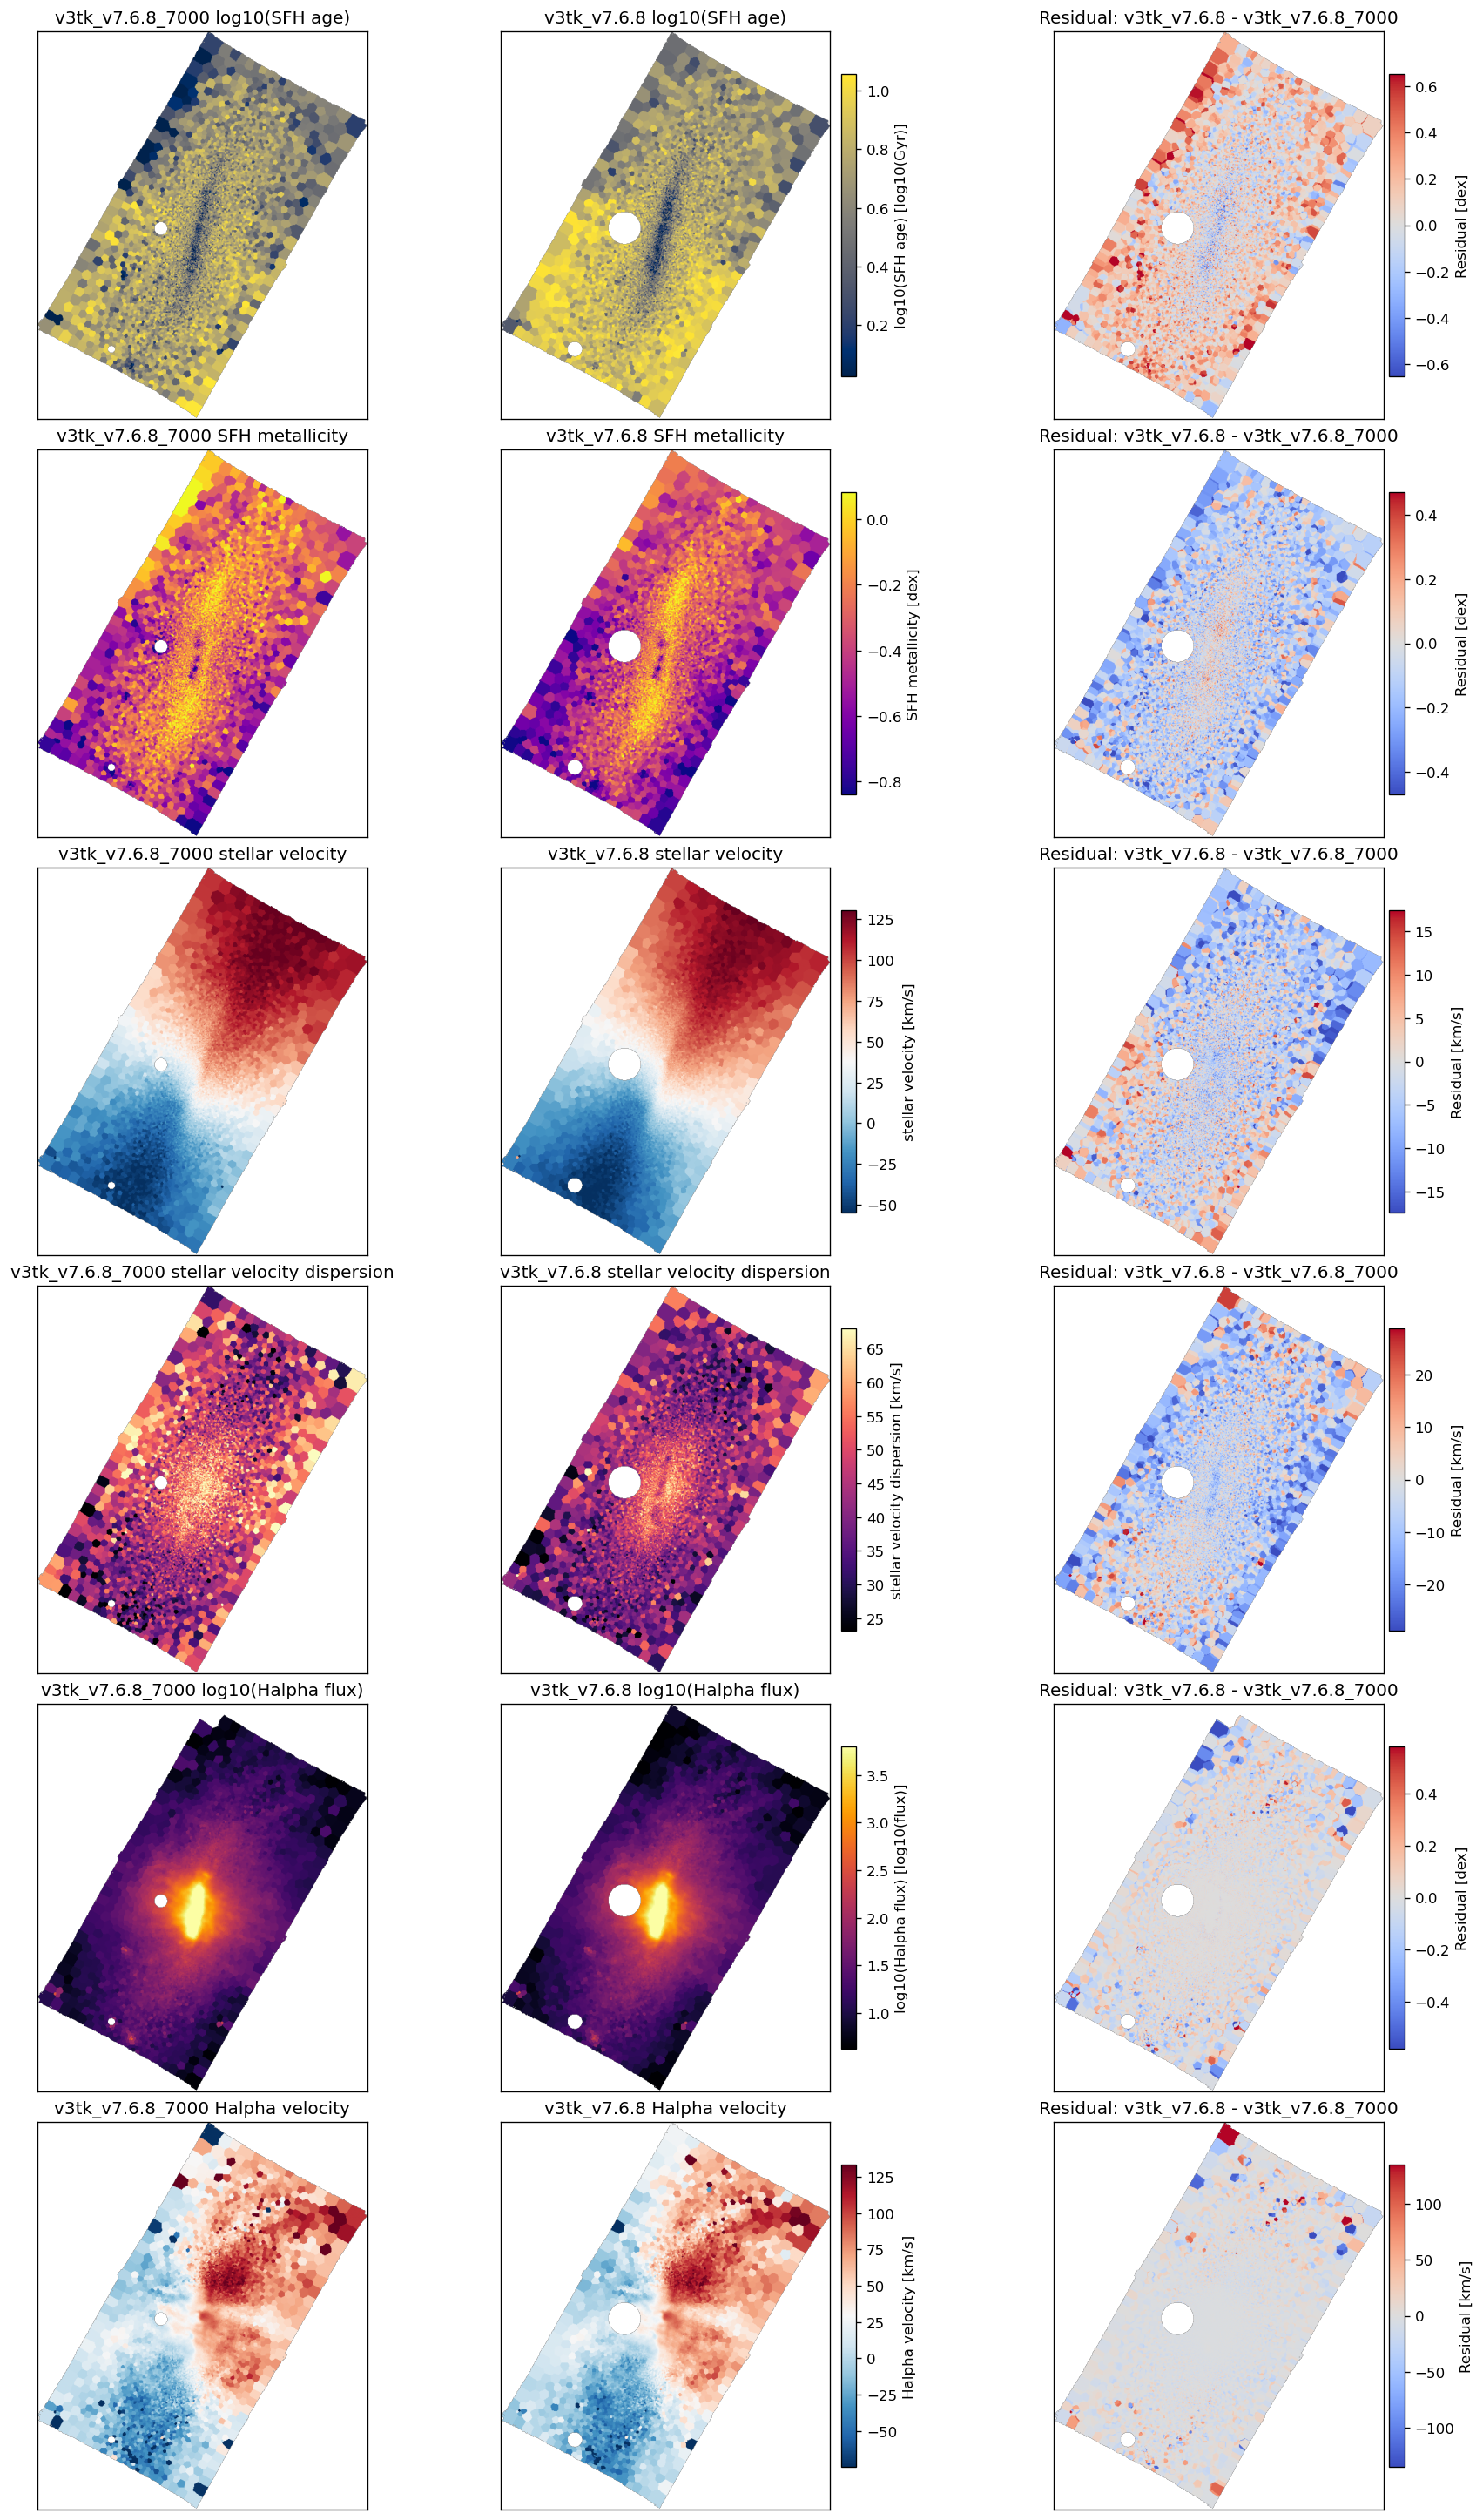

In [3]:
fig, axes = plt.subplots(len(PROPERTIES), 3, figsize=(15.0, 4.0 * len(PROPERTIES)), constrained_layout=True)
if axes.ndim == 1:
    axes = axes[None, :]

for row, (prop_key, prop) in enumerate(PROPERTIES.items()):
    ref = map_data[REF_KEY][prop_key]
    test = map_data[TEST_KEY][prop_key]
    
    use_log = prop.get('scatter_log_axes', False)
    if use_log:
        ref_plot = np.log10(np.where(ref > 0, ref, np.nan))
        test_plot = np.log10(np.where(test > 0, test, np.nan))
        label_suffix = f"log10({prop['label']})"
        unit_str = f"log10({prop['unit']})"
    else:
        ref_plot = ref
        test_plot = test
        label_suffix = prop['label']
        unit_str = prop['unit']
        
    combined = np.concatenate([ref_plot.ravel(), test_plot.ravel()])
    vmin, vmax = finite_limits(combined)

    im0 = axes[row, 0].imshow(ref_plot, origin='lower', cmap=prop['cmap'], vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f"{RUNS[REF_KEY]['label']} {label_suffix}")
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

    im1 = axes[row, 1].imshow(test_plot, origin='lower', cmap=prop['cmap'], vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f"{RUNS[TEST_KEY]['label']} {label_suffix}")
    axes[row, 1].set_xticks([])
    axes[row, 1].set_yticks([])
    fig.colorbar(im1, ax=axes[row, :2], shrink=0.78, pad=0.012, label=f"{label_suffix} [{unit_str}]")

    if use_log:
        residual = test_plot - ref_plot
        residual_label = "Residual [dex]"
    else:
        residual = test - ref
        residual_label = f"Residual [{prop['unit']}]"
        
    rmin, rmax = symmetric_limits(residual)
    im2 = axes[row, 2].imshow(residual, origin='lower', cmap='coolwarm', vmin=rmin, vmax=rmax)
    axes[row, 2].set_title(f"Residual: {RUNS[TEST_KEY]['label']} - {RUNS[REF_KEY]['label']}")
    axes[row, 2].set_xticks([])
    axes[row, 2].set_yticks([])
    fig.colorbar(im2, ax=axes[row, 2], shrink=0.78, pad=0.012, label=residual_label)

plt.show()


## Build Pairwise Tables

Each table uses common finite pixels between the fiducial `_7000` product and the comparison product. Residuals are `v3tk_v7.6.8 - v3tk_v7.6.8_7000`.


In [4]:
def property_table(prop_key):
    ref = map_data[REF_KEY][prop_key]
    test = map_data[TEST_KEY][prop_key]
    finite = np.isfinite(ref) & np.isfinite(test)
    yy, xx = np.where(finite)
    table = pd.DataFrame({
        'x': xx,
        'y': yy,
        'ref': ref[finite],
        'test': test[finite],
    })
    table['residual'] = table['test'] - table['ref']
    return table

comparison_tables = {prop_key: property_table(prop_key) for prop_key in PROPERTIES}

summary_rows = []
for prop_key, prop in PROPERTIES.items():
    table = comparison_tables[prop_key]
    residual = table['residual'].to_numpy(dtype=float)
    summary_rows.append({
        'property': prop['label'],
        'unit': prop['unit'],
        'n_common_finite_pixels': len(table),
        f"median_{RUNS[REF_KEY]['label']}": np.nanmedian(table['ref']),
        f"median_{RUNS[TEST_KEY]['label']}": np.nanmedian(table['test']),
        'median_residual_test_minus_fiducial': np.nanmedian(residual),
        'mean_residual_test_minus_fiducial': np.nanmean(residual),
        'nmad_residual': nmad(residual),
        'p16_residual': np.nanpercentile(residual, 16),
        'p84_residual': np.nanpercentile(residual, 84),
        'corrcoef': np.corrcoef(table['ref'], table['test'])[0, 1] if len(table) > 1 else np.nan,
        'n_positive_residual': int((residual > 0).sum()),
        'n_negative_residual': int((residual < 0).sum()),
    })

summary = pd.DataFrame(summary_rows)
display(summary)


,property,unit,n_common_finite_pixels,median_v3tk_v7.6.8_7000,median_v3tk_v7.6.8,median_residual_test_minus_fiducial,mean_residual_test_minus_fiducial,nmad_residual,p16_residual,p84_residual,corrcoef,n_positive_residual,n_negative_residual
0,SFH age,Gyr,177500,4.925873,5.960473,1.058817,1.137723,2.131173,-0.983438,3.429160,0.534505,121914,55586
1,SFH metallicity,dex,177500,-0.303573,-0.394088,-0.092158,-0.092343,0.142307,-0.236515,0.052088,0.725018,46048,131452
2,stellar velocity,km/s,177500,53.445818,49.728595,-2.091342,-2.131822,5.721563,-7.764260,3.432558,0.994658,62810,114690
3,stellar velocity dispersion,km/s,177500,47.875719,41.985591,-5.356977,-5.425840,9.456858,-15.276286,4.278243,0.410557,50200,127300
4,Halpha flux,flux,177500,22.148083,21.872223,-0.160535,1.516183,3.849858,-5.159683,5.036987,0.999124,85509,91991
5,Halpha velocity,km/s,177500,32.710389,28.421357,-2.197783,0.344885,8.584913,-11.133584,8.036143,0.738847,70546,106954


## Pairwise And Residual Scatter Plots

The left column compares the two values directly. The right column plots residuals against the fiducial `_7000` value.


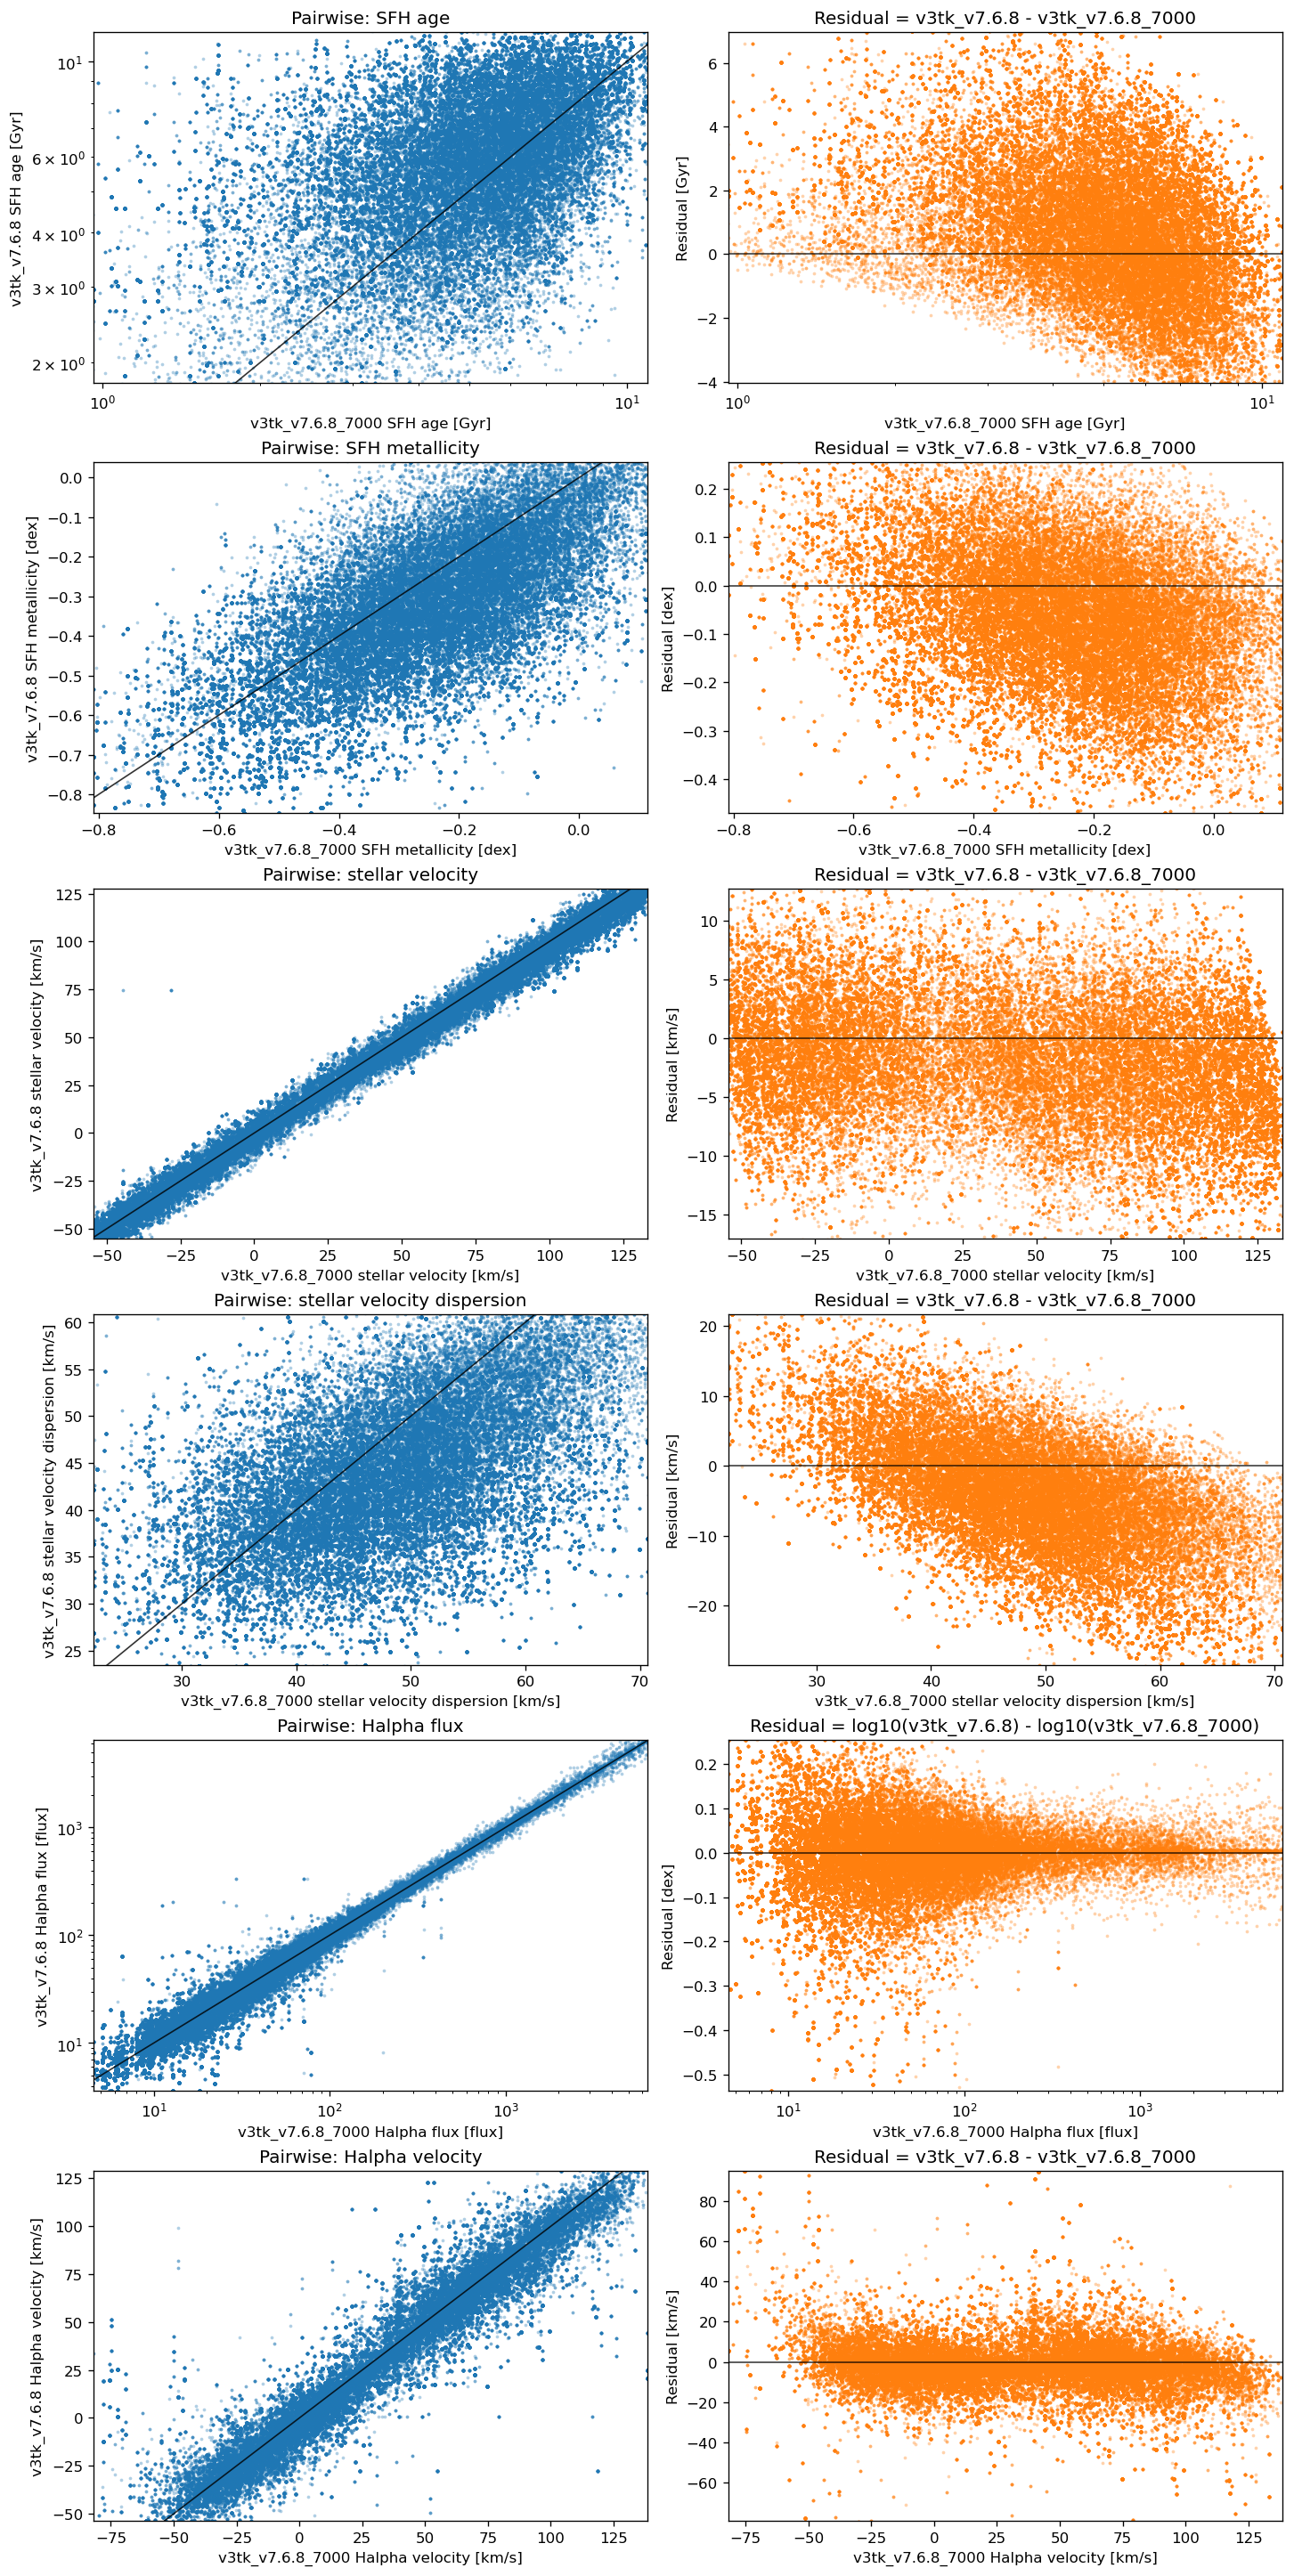

In [5]:
fig, axes = plt.subplots(len(PROPERTIES), 2, figsize=(12.0, 4.0 * len(PROPERTIES)), constrained_layout=True)
if axes.ndim == 1:
    axes = axes[None, :]

for row, (prop_key, prop) in enumerate(PROPERTIES.items()):
    table = comparison_tables[prop_key]
    x = table['ref'].to_numpy(dtype=float)
    y = table['test'].to_numpy(dtype=float)
    residual = table['residual'].to_numpy(dtype=float)

    ax = axes[row, 0]
    ax.scatter(x, y, s=5, alpha=0.35, linewidths=0, color='tab:blue')
    use_log_axes = prop.get('scatter_log_axes', False)
    use_log_residual = prop.get('scatter_log_residual', False)
    if use_log_axes:
        positive = (x > 0) & (y > 0)
        x_plot = x[positive]
        y_plot = y[positive]
        if use_log_residual:
            residual_plot = np.log10(y_plot) - np.log10(x_plot)
        else:
            residual_plot = residual[positive]
    else:
        x_plot = x
        y_plot = y
        residual_plot = residual

    xlo, xhi = finite_limits(x_plot)
    ylo, yhi = finite_limits(y_plot)
    line_lo = min(xlo, ylo)
    line_hi = max(xhi, yhi)
    ax.plot([line_lo, line_hi], [line_lo, line_hi], color='black', lw=1.0, alpha=0.8)
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.set_xlabel(f"{RUNS[REF_KEY]['label']} {prop['label']} [{prop['unit']}]")
    ax.set_ylabel(f"{RUNS[TEST_KEY]['label']} {prop['label']} [{prop['unit']}]")
    if use_log_axes:
        ax.set_xscale('log')
        ax.set_yscale('log')
    ax.set_title(f"Pairwise: {prop['label']}")

    ax = axes[row, 1]
    ax.axhline(0, color='black', lw=1.0, alpha=0.75)
    ax.scatter(x_plot, residual_plot, s=5, alpha=0.35, linewidths=0, color='tab:orange')
    xlo, xhi = finite_limits(x_plot)
    ylo, yhi = finite_limits(residual_plot)
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.set_xlabel(f"{RUNS[REF_KEY]['label']} {prop['label']} [{prop['unit']}]")
    if use_log_residual:
        ax.set_ylabel('Residual [dex]')
        ax.set_title(f"Residual = log10({RUNS[TEST_KEY]['label']}) - log10({RUNS[REF_KEY]['label']})")
    else:
        ax.set_ylabel(f"Residual [{prop['unit']}]")
        ax.set_title(f"Residual = {RUNS[TEST_KEY]['label']} - {RUNS[REF_KEY]['label']}")
    if use_log_axes:
        ax.set_xscale('log')

plt.show()


## Largest Residuals

Show the largest absolute residual pixels for each requested property.


In [6]:
largest_residual_tables = {}
for prop_key, prop in PROPERTIES.items():
    table = comparison_tables[prop_key].copy()
    table['abs_residual'] = table['residual'].abs()
    largest = table.sort_values('abs_residual', ascending=False).head(15)
    largest_residual_tables[prop_key] = largest
    print(f"\n{prop['label']} largest absolute residuals")
    display(largest[['x', 'y', 'ref', 'test', 'residual', 'abs_residual']])



SFH age largest absolute residuals


,x,y,ref,test,residual,abs_residual
15099,315,119,0.336321,12.222861,11.886540,11.886540
14127,307,115,1.433036,12.569795,11.136758,11.136758
13892,308,114,1.433036,12.569795,11.136758,11.136758
13658,308,113,1.433036,12.569795,11.136758,11.136758
13657,307,113,1.433036,12.569795,11.136758,11.136758
13190,308,111,1.433036,12.569795,11.136758,11.136758
13891,307,114,1.433036,12.569795,11.136758,11.136758
13424,308,112,1.433036,12.569795,11.136758,11.136758
14366,307,116,1.433036,12.222861,10.789825,10.789825
14373,314,116,1.433036,12.222861,10.789825,10.789825



SFH metallicity largest absolute residuals


,x,y,ref,test,residual,abs_residual
59005,148,247,-0.436461,-1.49,-1.053539,1.053539
31346,30,170,-0.477051,-1.49,-1.012949,1.012949
31347,31,170,-0.477051,-1.49,-1.012949,1.012949
31704,31,171,-0.477051,-1.49,-1.012949,1.012949
30986,28,169,-0.477051,-1.49,-1.012949,1.012949
30985,27,169,-0.477051,-1.49,-1.012949,1.012949
30990,32,169,-0.497870,-1.49,-0.992130,0.992130
30991,33,169,-0.497870,-1.49,-0.992130,0.992130
31348,32,170,-0.497870,-1.49,-0.992130,0.992130
31349,33,170,-0.497870,-1.49,-0.992130,0.992130



stellar velocity largest absolute residuals


...

,x,y,ref,test,residual,abs_residual
15099,315,119,378.760804,27.396076,-351.364728,351.364728
14614,315,117,378.760804,41.780217,-336.980587,336.980587
14375,316,116,378.760804,41.780217,-336.980587,336.980587
15101,317,119,378.760804,41.780217,-336.980587,336.980587
15100,316,119,378.760804,41.780217,-336.980587,336.980587
14858,318,118,378.760804,41.780217,-336.980587,336.980587
14857,317,118,378.760804,41.780217,-336.980587,336.980587
14855,315,118,378.760804,41.780217,-336.980587,336.980587
14374,315,116,378.760804,41.780217,-336.980587,336.980587
14856,316,118,378.760804,41.780217,-336.980587,336.980587



Halpha flux largest absolute residuals


,x,y,ref,test,residual,abs_residual
69895,260,277,18181.508742,26007.374502,7825.865760,7825.865760
67397,266,270,21658.096970,28807.503701,7149.406731,7149.406731
68821,259,274,14105.654383,19800.612152,5694.957769,5694.957769
69539,261,276,30300.015286,35689.888624,5389.873338,5389.873338
69537,259,276,14897.980271,20236.542502,5338.562231,5338.562231
68108,261,272,26205.604566,21431.608610,-4773.995956,4773.995956
69180,260,275,23096.202109,27856.321670,4760.119561,4760.119561
68109,262,272,25485.350668,30170.269392,4684.918724,4684.918724
73108,264,286,25600.336249,21064.089551,-4536.246698,4536.246698
69540,262,276,40201.373304,35689.888624,-4511.484681,4511.484681



Halpha velocity largest absolute residuals


,x,y,ref,test,residual,abs_residual
176063,309,626,-402.65216,30.828563,433.480723,433.480723
177499,294,663,-402.65216,25.623290,428.275449,428.275449
176857,313,638,-402.65216,25.623290,428.275449,428.275449
176884,288,639,-402.65216,25.623290,428.275449,428.275449
176883,287,639,-402.65216,25.623290,428.275449,428.275449
176882,286,639,-402.65216,25.623290,428.275449,428.275449
176881,285,639,-402.65216,25.623290,428.275449,428.275449
176880,284,639,-402.65216,25.623290,428.275449,428.275449
176879,283,639,-402.65216,25.623290,428.275449,428.275449
176878,282,639,-402.65216,25.623290,428.275449,428.275449


## Notes For Reading This Notebook

- The `_7000` product is the fiducial/reference product throughout.
- Residual maps and scatter residuals use `v3tk_v7.6.8 - v3tk_v7.6.8_7000`.
- The notebook compares `AGE`, `METAL`, `V`, `SIGMA`, `HA6562_FLUX`, and `HA6562_VEL` only.
